# Cross-Environment Generalization

This notebook loads `generalization.xlsx`, restricts attention to the test rows, computes CIP and AR, and produces the tables used in the numerical-results subsection.


---
### Helper functions
---


In [ ]:
## Helper functions
POLICIES = [
    {
        "suffix": "P",
        "code": "pi_P",
        "label": "Capped",
        "title": "Capped policy",
        "cost_col": "poisson_std_10_L6_c1_2",
    },
    {
        "suffix": "E",
        "code": "pi_E",
        "label": "Discounted-pipeline",
        "title": "Discounted-pipeline policy",
        "cost_col": "exponential_std100_L6_c1_2",
    },
    {
        "suffix": "N",
        "code": "pi_N",
        "label": "Hybrid",
        "title": "Hybrid policy",
        "cost_col": "normal_std30_L6_c1_2",
    },
    {
        "suffix": "BS",
        "code": "pi_BS",
        "label": "Base-stock",
        "title": "Base-stock policy",
        "cost_col": "avg_cost_basestock",
    },
]

LEARNED_POLICIES = [policy for policy in POLICIES if policy["suffix"] != "BS"]
INSTANCE_COLUMNS = ["distribution", "demand_mean", "demand_std", "lead_time", "cost_ratio"]

DIST_GROUP_MAP = {
    "beta": "Bounded continuous",
    "cunif": "Bounded continuous",
    "tri": "Bounded continuous",
    "binom": "Bounded discrete",
    "dunif": "Bounded discrete",
    "gamma": "Light/moderate unbounded",
    "geom": "Light/moderate unbounded",
    "negbin": "Light/moderate unbounded",
    "normal": "Light/moderate unbounded",
    "weib": "Light/moderate unbounded",
    "logn": "Heavy-tailed / skewed",
    "pareto": "Heavy-tailed / skewed",
    "zinb": "Heavy-tailed / skewed",
}

DIST_GROUP_ORDER = [
    "Bounded continuous",
    "Bounded discrete",
    "Light/moderate unbounded",
    "Heavy-tailed / skewed",
]

DIST_GROUP_LABELS = [
    "Category (i)",
    "Category (ii)",
    "Category (iii)",
    "Category (iv)",
]


def summarize(group_cols):
    grouped = df.groupby(group_cols, dropna=False)
    agg = {f"{policy['suffix']}_CIP": (f"CIP_{policy['suffix']}", "mean") for policy in POLICIES}
    agg.update({f"{policy['suffix']}_AR": (f"AR_{policy['suffix']}", "mean") for policy in POLICIES})
    agg["n"] = ("distribution", "size")
    return grouped.agg(**agg).reset_index().round(2)


def build_overall_table(frame):
    rows = []
    for policy in POLICIES:
        suffix = policy["suffix"]
        rows.append(
            {
                "Policy": policy["code"],
                "Mean CIP (\\%)": frame[f"CIP_{suffix}"].mean(),
                "Median CIP (\\%)": frame[f"CIP_{suffix}"].median(),
                "AR": frame[f"AR_{suffix}"].mean(),
            }
        )
    return pd.DataFrame(rows).round(2)


def build_policy_performance_table(frame, group_col, group_label):
    agg = {
        "Capped_CIP": ("CIP_P", "mean"),
        "Capped_AR": ("AR_P", "mean"),
        "DiscountedPipeline_CIP": ("CIP_E", "mean"),
        "DiscountedPipeline_AR": ("AR_E", "mean"),
        "Hybrid_CIP": ("CIP_N", "mean"),
        "Hybrid_AR": ("AR_N", "mean"),
        "BaseStock_AR": ("AR_BS", "mean"),
        "n": ("distribution", "size"),
    }
    return (
        frame.groupby(group_col, dropna=False)
        .agg(**agg)
        .reset_index()
        .rename(columns={group_col: group_label})
        .round(2)
    )


def assign_quantile_groups(frame, source_col, quantiles, labels, output_col):
    quantile_edges = frame[source_col].quantile(quantiles).to_list()
    bins = [-np.inf, *quantile_edges, np.inf]
    frame[output_col] = pd.cut(frame[source_col], bins=bins, labels=labels, ordered=True)
    return bins


def build_group_panel(frame, group_col, group_values, value_col, labels=None):
    labels = labels or group_values
    return pd.DataFrame(
        {
            label: frame.loc[frame[group_col] == group_value, value_col].reset_index(drop=True)
            for group_value, label in zip(group_values, labels)
        }
    )


def make_legend_handles(median_lw=2.5, mean_size=7, outlier_size=8, median_label="Median"):
    return [
        Line2D([0], [0], color="black", lw=median_lw, label=median_label),
        Line2D(
            [0],
            [0],
            marker="v",
            color="black",
            markerfacecolor="black",
            markersize=mean_size,
            linestyle="None",
            label="Mean",
        ),
        Line2D(
            [0],
            [0],
            marker="+",
            color="black",
            markersize=outlier_size,
            linestyle="None",
            label="Outlier",
        ),
    ]


def format_axis(ax, tick_size=12, label_size=12, title_size=14, rotation=0):
    ax.tick_params(axis="x", labelrotation=rotation, labelsize=tick_size)
    ax.tick_params(axis="y", labelsize=tick_size)
    ax.xaxis.label.set_size(label_size)
    ax.yaxis.label.set_size(label_size)
    ax.title.set_fontsize(title_size)


def to_latex(df_table, index=False, caption=None, label=None):
    return df_table.to_latex(index=index, escape=False, caption=caption, label=label)



#### Plotting Boxplots

In [ ]:
def boxplot_on_axis(
    ax,
    data,
    cols,
    box_colors,
    labels=None,
    title=None,
    xlabel=None,
    ylabel=None,
    refline=None,
    whis=(5, 95),
    showmeans=True,
    showfliers=True,
    vert=False,
):
    values = [data[col].dropna() for col in cols]

    bp = ax.boxplot(
        values,
        patch_artist=True,
        showfliers=showfliers,
        showmeans=showmeans,
        widths=[0.65] * len(cols),
        whis=whis,
        boxprops=dict(facecolor="white", lw=1.25, alpha=0.5),
        capprops=dict(lw=2.0, alpha=1, zorder=10),
        whiskerprops=dict(alpha=1, lw=1.5),
        flierprops=dict(alpha=1, lw=0.5, marker="+"),
        medianprops=dict(lw=2.5, color="black"),
        meanprops=dict(alpha=1, marker="v"),
        notch=False,
        vert=vert,
    )

    def safe_set(artists, idx, setter):
        if idx < len(artists):
            setter(artists[idx])

    for i, color in enumerate(box_colors):
        safe_set(bp["boxes"], i, lambda art: (art.set_edgecolor(color), art.set_facecolor(color)))
        safe_set(bp["whiskers"], 2 * i, lambda art: art.set_color(color))
        safe_set(bp["whiskers"], 2 * i + 1, lambda art: art.set_color(color))
        safe_set(bp["caps"], 2 * i, lambda art: art.set_color(color))
        safe_set(bp["caps"], 2 * i + 1, lambda art: art.set_color(color))
        safe_set(bp["medians"], i, lambda art: art.set_color("black"))

        if i < len(bp.get("fliers", [])):
            flier = bp["fliers"][i]
            flier.set_markeredgecolor(color)
            flier.set_markerfacecolor(color)
            flier.set_color(color)
            flier.set_alpha(1)

        if "means" in bp and i < len(bp["means"]):
            mean_marker = bp["means"][i]
            mean_marker.set_markeredgecolor("black")
            mean_marker.set_markerfacecolor("black")
            mean_marker.set_color("black")
            mean_marker.set_alpha(1)

    labels = labels or cols
    tick_positions = range(1, len(labels) + 1)

    if vert:
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(labels)
        if ylabel is not None:
            ax.set_ylabel(ylabel)
        if xlabel is not None:
            ax.set_xlabel(xlabel)
        if refline is not None:
            ax.axhline(refline, linestyle="--", lw=1.2, color="black", alpha=0.8)
    else:
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(labels)
        if xlabel is not None:
            ax.set_xlabel(xlabel)
        if ylabel is not None:
            ax.set_ylabel(ylabel)
        if refline is not None:
            ax.axvline(refline, linestyle="--", lw=1.2, color="black", alpha=0.8)

    if title is not None:
        ax.set_title(title)

    ax.grid(True, linestyle="-", alpha=0.4)
    return bp

---
### Pre-processing step
---


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rc("text", usetex=True)
plt.rc("font", family="serif")


In [3]:
path = "generalization.xlsx"
df = pd.read_excel(path, sheet_name="S5 merged")

# Keep only test rows and compute policy metrics used throughout the notebook.
df = df.loc[df["mode"].astype(str).str.lower().eq("test")].copy()

for policy in LEARNED_POLICIES:
    suffix = policy["suffix"]
    df[f"CIP_{suffix}"] = 100 * (1 - df[policy["cost_col"]] / df["avg_cost_basestock"])

df["CIP_BS"] = 0.0

rank_columns = [policy["cost_col"] for policy in POLICIES]
rank_df = df[rank_columns].rank(axis=1, method="average", ascending=True)
rank_df.columns = [f"AR_{policy['suffix']}" for policy in POLICIES]
df = pd.concat([df, rank_df], axis=1)

df["CV"] = df["demand_std"] / df["demand_mean"]
df["dist_group"] = df["distribution"].map(DIST_GROUP_MAP)


---
### Some Important Stats
---


In [4]:
print("Number of test rows:", len(df))
print(
    "Number of distinct test instances:",
    df[INSTANCE_COLUMNS].drop_duplicates().shape[0],
)
print("Demand families:", df["distribution"].nunique())

family_instance_counts = (
    df[INSTANCE_COLUMNS]
    .drop_duplicates()
    .groupby("distribution")
    .size()
    .div(df["lead_time"].nunique() * df["cost_ratio"].nunique())
    .astype(int)
    .reset_index(name="num_mu_sigma_specs")
    .sort_values(["num_mu_sigma_specs", "distribution"], ascending=[False, True])
)

demand_specs = df[["distribution", "demand_mean", "demand_std"]].drop_duplicates().copy()
print("\nNumber of unique demand specifications (family, mu, sigma):", len(demand_specs))

print("\nDistinct (mu, sigma) specifications by family:")
print(family_instance_counts.to_string(index=False))


Number of test rows: 10064
Number of distinct test instances: 10064
Demand families: 13

Number of unique demand specifications (family, mu, sigma): 629

Distinct (mu, sigma) specifications by family:
distribution  num_mu_sigma_specs
        zinb                 150
        beta                 123
         tri                  51
       binom                  48
       gamma                  36
      pareto                  36
        weib                  36
      normal                  33
        logn                  30
      negbin                  30
       dunif                  27
       cunif                  19
        geom                  10


In [5]:
demand_specs = df[["distribution", "demand_mean", "demand_std"]].drop_duplicates().copy()

for value_col, label, sort_cols in [
    ("demand_mean", "demand mean", ["distribution", "demand_std"]),
    ("demand_std", "demand std", ["distribution", "demand_mean"]),
]:
    min_value = demand_specs[value_col].min()
    max_value = demand_specs[value_col].max()

    print(f"Rows with minimum {label}:")
    print(
        demand_specs[demand_specs[value_col] == min_value]
        .sort_values(sort_cols)
        .to_string(index=False)
    )

    print(f"\nRows with maximum {label}:")
    print(
        demand_specs[demand_specs[value_col] == max_value]
        .sort_values(sort_cols)
        .to_string(index=False)
    )
    print()


Rows with minimum demand mean:
distribution  demand_mean  demand_std
        zinb        0.075    0.354436

Rows with maximum demand mean:
distribution  demand_mean  demand_std
       gamma       1600.0  357.770876

Rows with minimum demand std:
distribution  demand_mean  demand_std
      pareto          1.2    0.244949

Rows with maximum demand std:
distribution  demand_mean  demand_std
      pareto     2.000000         inf
      pareto     3.000000         inf
      pareto     4.333333         inf
      pareto    10.000000         inf
      pareto    15.000000         inf
      pareto    20.000000         inf
      pareto    21.666667         inf
      pareto    30.000000         inf
      pareto    40.000000         inf
      pareto    43.333333         inf
      pareto    60.000000         inf
      pareto    86.666667         inf
      pareto   100.000000         inf
      pareto   150.000000         inf
      pareto   200.000000         inf
      pareto   216.666667         inf
 

In [6]:
print("\nStats of coefficient of variation:")
print(df["CV"].describe())



Stats of coefficient of variation:
count    1.006400e+04
mean              inf
std               NaN
min      8.111071e-03
25%      3.068783e-01
50%      5.748728e-01
75%      1.069045e+00
max               inf
Name: CV, dtype: float64


/Users/parshan/miniconda3/envs/spyder/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


---
### Overall generalization performance
---


In [7]:
overall = build_overall_table(df)
overall

# print(to_latex(
#     overall,
#     index=False,
#     caption="Overall performance on the test rows.",
#     label="tab:overall_generalization",
# ))


,Policy,Mean CIP (\%),Median CIP (\%),AR
0,pi_P,22.60,16.94,1.93
1,pi_E,21.75,15.92,2.17
2,pi_N,22.10,16.24,2.01
3,pi_BS,0.00,0.00,3.89


---
### Performance across lead times
---


In [8]:
lead_tbl = summarize(["lead_time"]).rename(columns={"lead_time": "L"})
lead_tbl

# print(to_latex(
#     lead_tbl,
#     index=False,
#     caption="Performance across lead times on the test rows.",
#     label="tab:lead_generalization",
# ))


,L,P_CIP,E_CIP,N_CIP,BS_CIP,P_AR,E_AR,N_AR,BS_AR,n
0,2,9.20,7.47,7.80,0.0,1.78,2.24,2.12,3.86,2516
1,4,18.86,17.84,18.32,0.0,1.87,2.24,1.99,3.89,2516
2,6,27.42,27.00,27.32,0.0,1.99,2.13,1.98,3.90,2516
3,8,34.90,34.70,34.94,0.0,2.06,2.07,1.95,3.91,2516


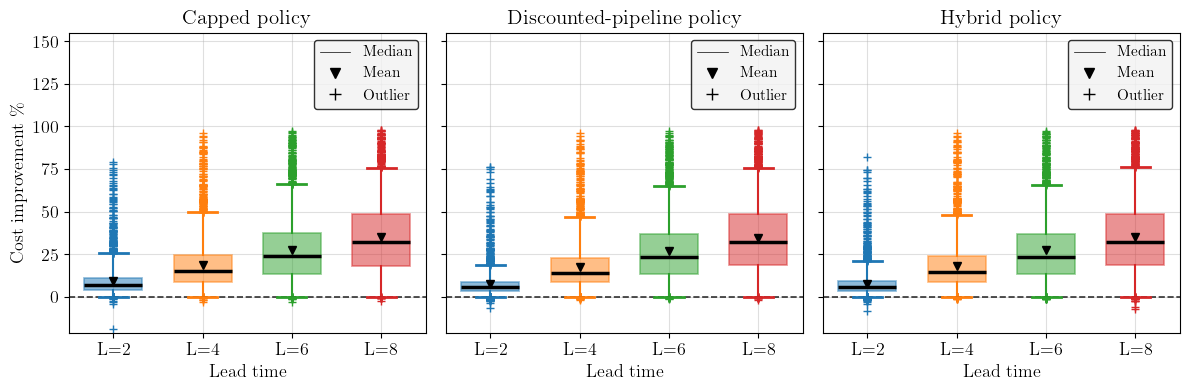

In [9]:
lead_times = sorted(df["lead_time"].dropna().unique())
lead_labels = [f"L={int(lead_time)}" for lead_time in lead_times]
lead_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"][: len(lead_times)]
legend_handles = make_legend_handles(median_lw=0.5)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, policy in zip(axes, LEARNED_POLICIES):
    panel = build_group_panel(df, "lead_time", lead_times, f"CIP_{policy['suffix']}", labels=lead_labels)
    boxplot_on_axis(
        ax=ax,
        data=panel,
        cols=panel.columns.tolist(),
        box_colors=lead_colors,
        labels=lead_labels,
        title=policy["title"],
        xlabel="Lead time",
        ylabel=r"Cost improvement  $\%$" if ax is axes[0] else None,
        refline=0,
        vert=True,
        showfliers=True,
    )
    ax.set_ylim([-21, 155])
    format_axis(ax, tick_size=13, label_size=13, title_size=15)
    ax.legend(
        handles=legend_handles,
        loc="upper right",
        facecolor="#f2f2f2",
        frameon=True,
        fancybox=True,
        edgecolor="black",
        fontsize=11,
    )

fig.tight_layout()
fig.savefig("leadtime_comparison.pdf", bbox_inches="tight")
plt.show()


In [10]:
lead_perf_tbl = build_policy_performance_table(df, "lead_time", "L")
lead_perf_tbl

# print(
#     lead_perf_tbl.to_latex(
#         index=False,
#         caption="Mean CIP and AR across lead times.",
#         label="tab:leadtime_cip_ar",
#         escape=False,
#     )
# )


,L,Capped_CIP,Capped_AR,DiscountedPipeline_CIP,DiscountedPipeline_AR,Hybrid_CIP,Hybrid_AR,BaseStock_AR,n
0,2,9.20,1.78,7.47,2.24,7.80,2.12,3.86,2516
1,4,18.86,1.87,17.84,2.24,18.32,1.99,3.89,2516
2,6,27.42,1.99,27.00,2.13,27.32,1.98,3.90,2516
3,8,34.90,2.06,34.70,2.07,34.94,1.95,3.91,2516


---
### Performance across cost ratios
---


In [11]:
cost_tbl = summarize(["cost_ratio"]).rename(columns={"cost_ratio": "R"})
cost_tbl

# print(to_latex(
#     cost_tbl,
#     index=False,
#     caption="Performance across cost ratios on the test rows.",
#     label="tab:cost_generalization",
# ))


,R,P_CIP,E_CIP,N_CIP,BS_CIP,P_AR,E_AR,N_AR,BS_AR,n
0,2,26.93,26.80,26.95,0.0,2.22,2.04,1.90,3.84,2516
1,4,23.35,22.84,23.11,0.0,1.98,2.14,1.98,3.91,2516
2,6,21.30,20.29,20.69,0.0,1.82,2.24,2.05,3.89,2516
3,10,18.80,17.07,17.63,0.0,1.68,2.28,2.12,3.92,2516


---
### Performance across demand distributions
---


In [12]:
dist_tbl = summarize(["distribution"]).sort_values("distribution").reset_index(drop=True)
dist_tbl

# print(to_latex(
#     dist_tbl,
#     index=False,
#     caption="Performance across demand distributions on the test rows.",
#     label="tab:dist_generalization",
# ))


,distribution,P_CIP,E_CIP,N_CIP,BS_CIP,P_AR,E_AR,N_AR,BS_AR,n
0,beta,27.14,25.30,25.85,0.0,1.79,2.22,2.00,3.99,1968
1,binom,50.96,48.99,50.61,0.0,1.81,2.26,1.94,4.00,768
2,cunif,23.17,22.30,22.56,0.0,1.42,2.49,2.10,4.00,304
3,dunif,22.94,22.15,22.38,0.0,1.48,2.36,2.16,4.00,432
4,gamma,21.55,21.14,21.40,0.0,2.01,2.12,1.86,4.00,576
5,geom,8.84,9.24,9.26,0.0,2.68,1.65,1.84,3.83,160
6,logn,17.09,17.13,17.19,0.0,2.38,1.85,1.77,4.00,480
7,negbin,24.31,23.78,24.03,0.0,1.82,2.22,1.98,3.99,480
8,normal,39.21,37.24,37.92,0.0,1.38,2.63,2.00,4.00,528
9,pareto,22.90,22.78,22.81,0.0,2.25,1.94,1.82,3.99,576


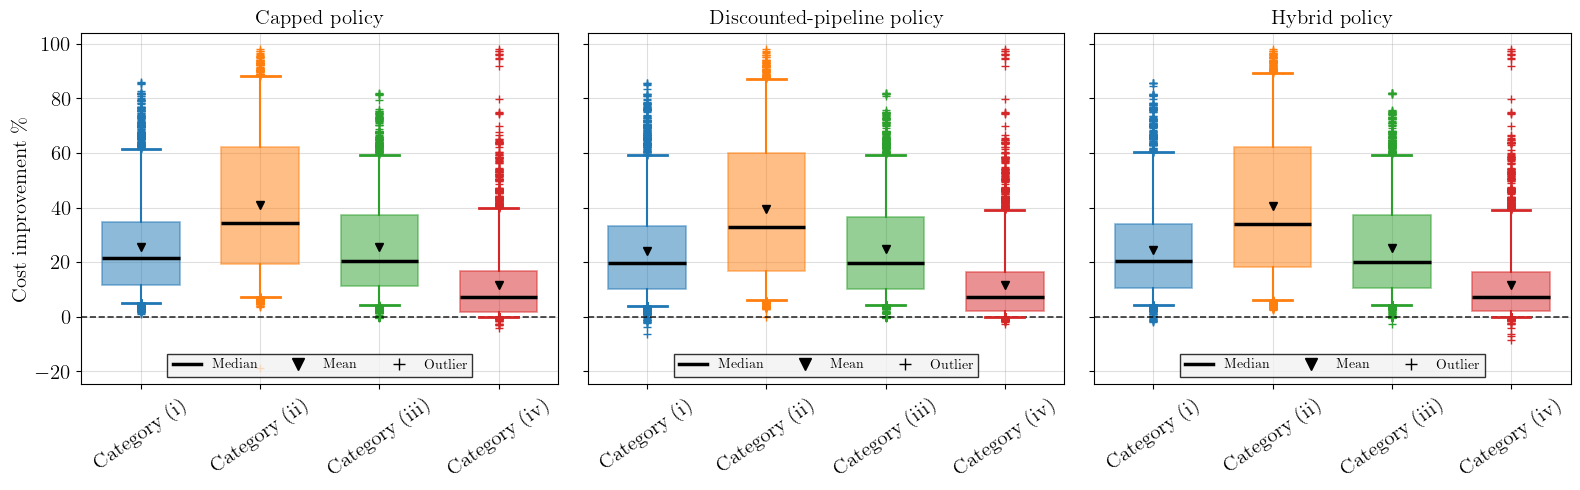

In [13]:
group_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
legend_handles = make_legend_handles(mean_size=8, outlier_size=9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, policy in zip(axes, LEARNED_POLICIES):
    panel = build_group_panel(
        df,
        "dist_group",
        DIST_GROUP_ORDER,
        f"CIP_{policy['suffix']}",
        labels=DIST_GROUP_LABELS,
    )
    boxplot_on_axis(
        ax=ax,
        data=panel,
        cols=panel.columns.tolist(),
        box_colors=group_colors,
        labels=DIST_GROUP_LABELS,
        title=policy["title"],
        ylabel=r"Cost improvement $\%$" if ax is axes[0] else None,
        refline=0,
        vert=True,
        showfliers=True,
    )
    format_axis(ax, tick_size=15, label_size=15, title_size=15, rotation=35)
    ax.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=3,
        frameon=True,
        fancybox=False,
        edgecolor="black",
        facecolor="#f2f2f2",
        fontsize=10,
    )

fig.tight_layout()
fig.savefig("dist_comparison.pdf", bbox_inches="tight")
plt.show()


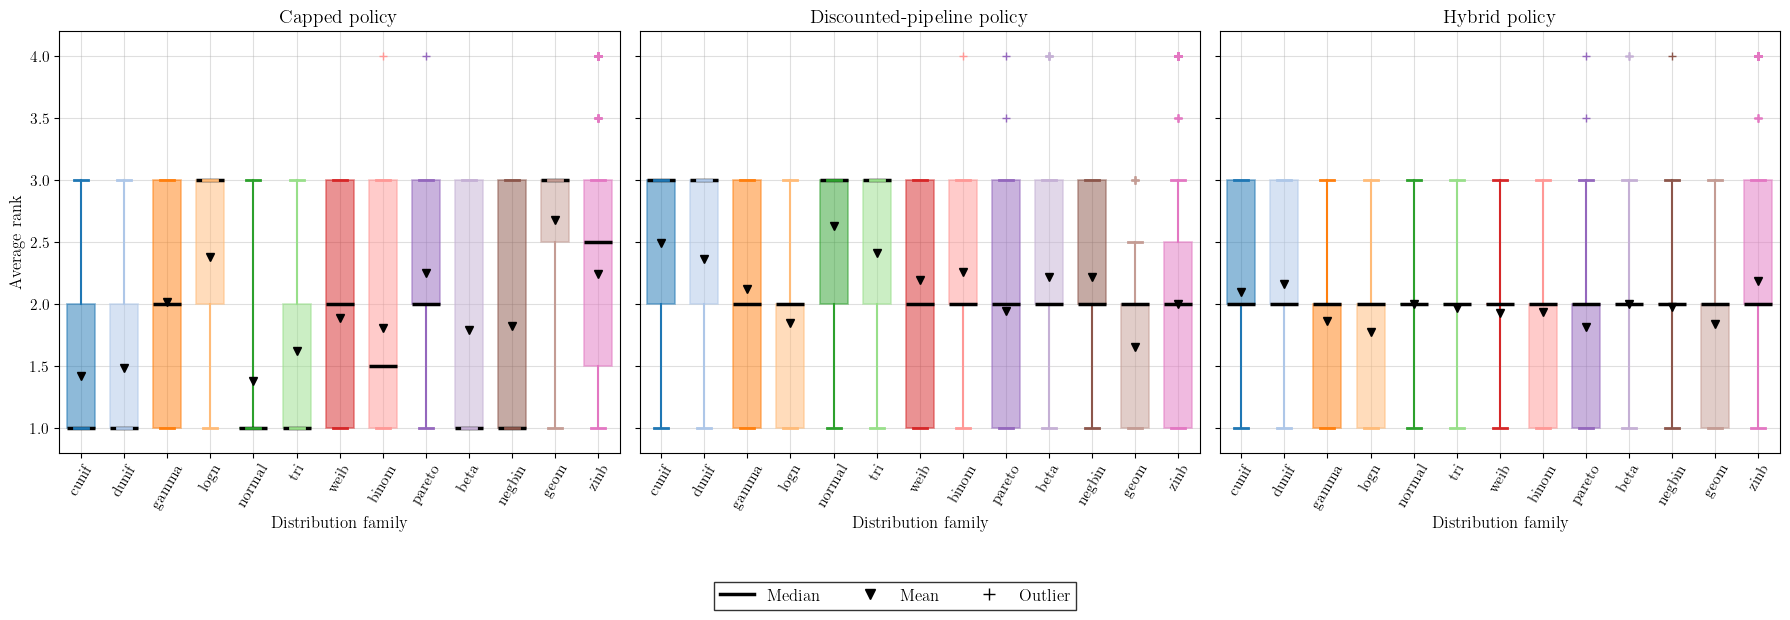

In [14]:
dist_order = (
    df.groupby("distribution")[["AR_P", "AR_E", "AR_N"]]
    .mean()
    .mean(axis=1)
    .sort_values(ascending=True)
    .index
    .tolist()
)

cmap = plt.get_cmap("tab20")
dist_colors = [cmap(i % 20) for i in range(len(dist_order))]
legend_handles = make_legend_handles(mean_size=7, outlier_size=8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, policy in zip(axes, LEARNED_POLICIES):
    panel = build_group_panel(df, "distribution", dist_order, f"AR_{policy['suffix']}")
    boxplot_on_axis(
        ax=ax,
        data=panel,
        cols=panel.columns.tolist(),
        box_colors=dist_colors,
        labels=dist_order,
        title=policy["title"],
        xlabel="Distribution family",
        ylabel="Average rank" if ax is axes[0] else None,
        refline=None,
        vert=True,
        showfliers=True,
    )
    format_axis(ax, tick_size=11 if ax is not axes[0] else 11, label_size=12, title_size=14, rotation=60)
    ax.set_ylim(0.8, 4.2)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(0.5, -0.04),
    fontsize=12,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


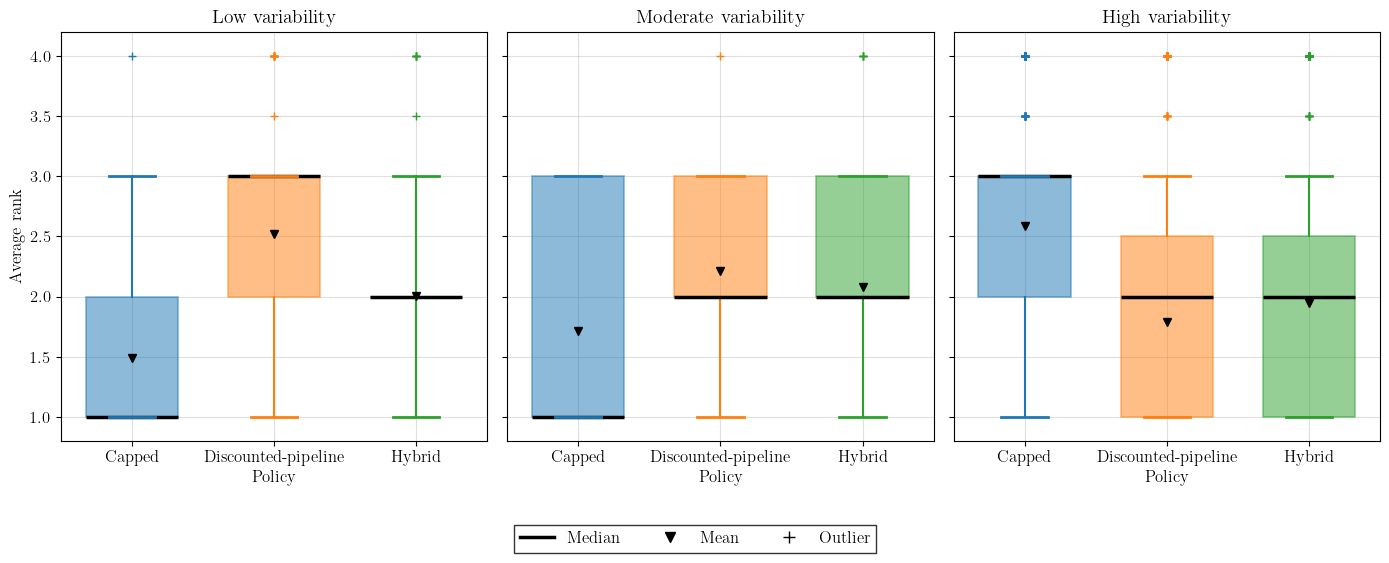

In [15]:
cv_labels = ["Low variability", "Moderate variability", "High variability"]
assign_quantile_groups(df, "CV", [1 / 3, 2 / 3], cv_labels, "cv_group_tercile")

policy_colors = ["tab:blue", "tab:orange", "tab:green"]
policy_labels = [policy["label"] for policy in LEARNED_POLICIES]
legend_handles = make_legend_handles(mean_size=7, outlier_size=8)

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharey=True)

for ax, cv_label in zip(axes, cv_labels):
    subset = df[df["cv_group_tercile"] == cv_label]
    panel = pd.DataFrame(
        {
            policy["label"]: subset[f"AR_{policy['suffix']}"] .reset_index(drop=True)
            for policy in LEARNED_POLICIES
        }
    )
    boxplot_on_axis(
        ax=ax,
        data=panel,
        cols=panel.columns.tolist(),
        box_colors=policy_colors,
        labels=policy_labels,
        title=cv_label,
        xlabel="Policy",
        ylabel="Average rank" if ax is axes[0] else None,
        refline=None,
        vert=True,
        showfliers=True,
    )
    format_axis(ax, tick_size=12, label_size=12, title_size=14)
    ax.set_ylim(0.8, 4.2)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(0.5, -0.03),
    fontsize=12,
)

fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


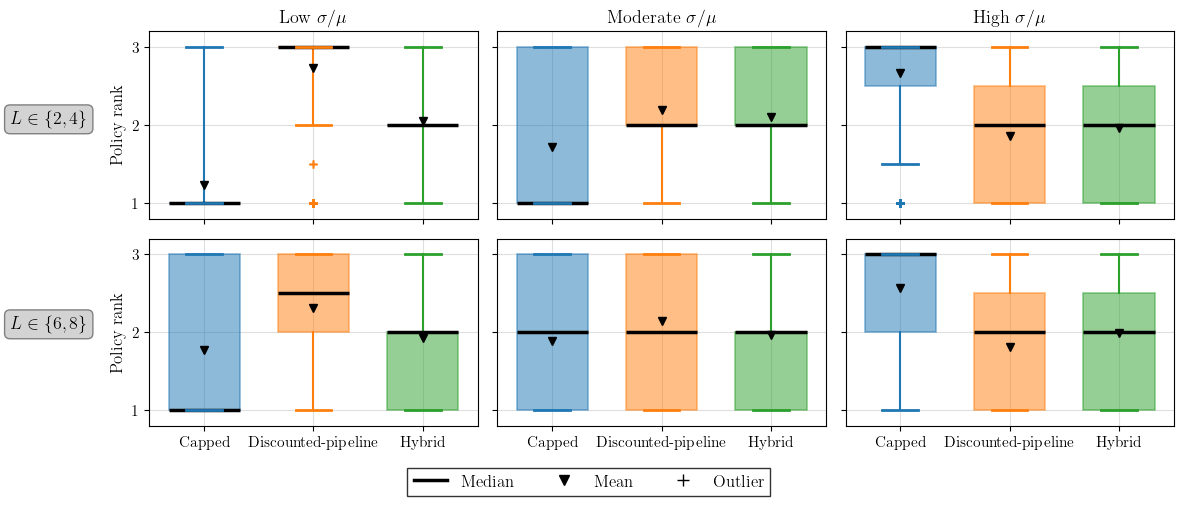

In [16]:
cv_labels = [r"Low $\sigma/\mu$", r"Moderate $\sigma/\mu$", r"High $\sigma/\mu$"]
assign_quantile_groups(df, "CV", [0.25, 0.75], cv_labels, "cv_group_quartile")

df["lead_time_bucket"] = pd.cut(
    df["lead_time"],
    bins=[1.5, 4.0, 8.0],
    labels=[r"$L \in \{2,4\}$", r"$L \in \{6,8\}$"],
    ordered=True,
)

lead_time_bucket_labels = [r"$L \in \{2,4\}$", r"$L \in \{6,8\}$"]
policy_colors = ["tab:blue", "tab:orange", "tab:green"]
policy_labels = [policy["label"] for policy in LEARNED_POLICIES]
legend_handles = make_legend_handles(mean_size=7, outlier_size=8)

fig, axes = plt.subplots(
    len(lead_time_bucket_labels),
    len(cv_labels),
    figsize=(12, 5),
    sharex=True,
    sharey=True,
)

for row_idx, lead_bucket in enumerate(lead_time_bucket_labels):
    for col_idx, cv_label in enumerate(cv_labels):
        ax = axes[row_idx, col_idx]
        subset = df[
            (df["lead_time_bucket"] == lead_bucket)
            & (df["cv_group_quartile"] == cv_label)
        ]
        panel = pd.DataFrame(
            {
                policy["label"]: subset[f"AR_{policy['suffix']}"] .reset_index(drop=True)
                for policy in LEARNED_POLICIES
            }
        )
        boxplot_on_axis(
            ax=ax,
            data=panel,
            cols=panel.columns.tolist(),
            box_colors=policy_colors,
            labels=policy_labels,
            title=cv_label if row_idx == 0 else None,
            ylabel="Policy rank" if col_idx == 0 else None,
            refline=None,
            vert=True,
            showfliers=True,
        )
        format_axis(ax, tick_size=11, label_size=12, title_size=13)
        ax.set_ylim(0.8, 3.2)
        ax.set_yticks([1, 2, 3])
        ax.set_yticklabels([1, 2, 3])

fig.text(
    0.05,
    0.75,
    r"$L \in \{2,4\}$",
    rotation=0,
    va="center",
    ha="center",
    fontsize=13,
    bbox=dict(facecolor="lightgray", edgecolor="gray", boxstyle="round,pad=0.3"),
)
fig.text(
    0.05,
    0.34,
    r"$L \in \{6,8\}$",
    rotation=0,
    va="center",
    ha="center",
    fontsize=13,
    bbox=dict(facecolor="lightgray", edgecolor="gray", boxstyle="round,pad=0.3"),
)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    bbox_to_anchor=(0.5, -0.02),
    fontsize=12,
)

fig.tight_layout(rect=[0.09, 0.06, 1, 1])
fig.savefig("AR_by_Lbucket_and_CV.pdf", bbox_inches="tight")
plt.show()
